# Digital Twin for HAADF and EDS



### Quick Start Code Cell

In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# first do lsof -i:9000
# kill {PID}

# if kernel is dying, reset the environment (click a different one then click back)

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"test/{d}/1") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("test/microscope/1"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database.... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:9000

  registered: test/scan/1
  registered: test/eds/1
  registered: test/stage/1
  registered: test/microscope/1
  property:   scan_device_address = test/scan/1
  property:   eds_device_address = test/eds/1
  property:   stage_device_address = test/stage/1

Done!
Starting device servers...
  Waiting for test/stage/1.... ✅ ready (1.0s)
  Waiting for test/scan/1... ✅ ready (0.0s)
  Waiting for test/eds/1... ✅ ready (0.0s)
Starting Microscope...
  Waiting for test/microscope/1.... ✅ ready (1.0s)

✅ All servers ready!


## 1. Connect to devices

In [4]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:9000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"

# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/microscope/1
test/scan/1
test/stage/1


In [5]:
scan = tango.DeviceProxy("test/scan/1")
mic = tango.DeviceProxy("test/microscope/1")

scan.set_timeout_millis(120_000)
mic.set_timeout_millis(120_000)

In [6]:
## helper funcs.
def get_image(dwell=10e-6, imsize=512):
    scan.dwell_time = dwell
    scan.imsize  = imsize

    json_meta, raw_bytes = mic.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

### Begin

Stage position: [-4.793865e-06 -3.685302e-06 -9.813438e-05 -3.136000e-06]


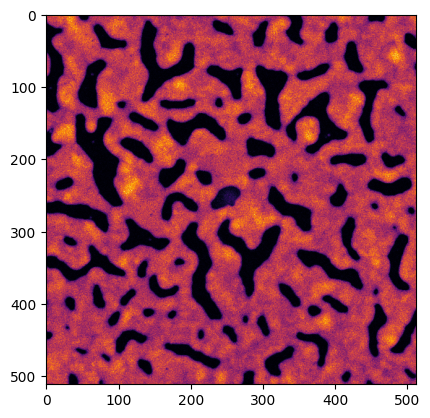

In [7]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

# Get Stage
starting_position = mic.get_stage()
print('Stage position:', starting_position)

In [8]:
# First time will take ~35 seconds:
mic.set_screen_current(60) # pA


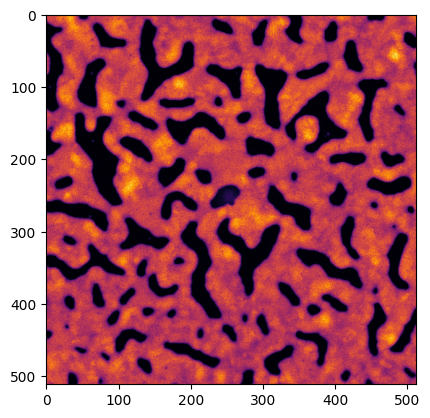

In [9]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

In [10]:
set_currents = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
real_currents = []
meta_images = []
for c in set_currents:
    print(f"\nSetting screen current to {c} pA...")
    mic.set_screen_current(c)

    time.sleep(2)  # wait for stabilization

    real_screen_current = mic.get_screen_current() * 1e12
    real_currents.append(real_screen_current)
    # auto-focus
    mic.auto_focus()

    # get 10 images
    images = []
    for i in range(10):
        image, metadata = get_image(dwell=10e-6, imsize=512)
        images.append(image)
    meta_images.append(images)




Setting screen current to 20 pA...

Setting screen current to 40 pA...

Setting screen current to 60 pA...

Setting screen current to 80 pA...

Setting screen current to 100 pA...

Setting screen current to 120 pA...

Setting screen current to 140 pA...

Setting screen current to 160 pA...

Setting screen current to 180 pA...

Setting screen current to 200 pA...


In [ ]:
meta_images = np.array(meta_images)  
real_currents = np.array(real_currents)

print(meta_images.shape)

In [ ]:
np.savez(
    "beam_current_series.npz",
    images=meta_images,
    currents=real_currents,
    set_currents=np.array(set_currents)
)

In [ ]:
fig, ax = plt.subplots(len(set_currents), 10, figsize=(12, 12), dpi=150)

for i in range(len(set_currents)):
    for j in range(10):
        ax[i, j].imshow(meta_images[i, j], cmap='gray')
        ax[i, j].axis('off')
        
        if j == 0:
            ax[i, j].set_ylabel(f"{real_currents[i]:.0f} pA")

fig.tight_layout()